In [2]:
# ═══════════════════════════════════════════════════════════
# TWIN-RBI MONGSTAD — Análisis Exploratorio de Datos (EDA)
# ═══════════════════════════════════════════════════════════
# Refinería Equinor Mongstad — Crudo 75% Troll / 25% Arab Medium
# Dataset: 5 años operacionales 2018-2022 · 12 activos · 21,912 registros
# Autor: Luis Fernando Carvallo
# ═══════════════════════════════════════════════════════════

#### Import librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#### Lectura de los dataset 

In [4]:


# Estilo
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor']   = '#F8F8F8'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.family']      = 'Arial'

COLORS = {
    'navy':   '#0D1B2A',
    'teal':   '#1D9E75',
    'blue':   '#185FA5',
    'amber':  '#BA7517',
    'red':    '#A32D2D',
    'coral':  '#D85A30',
    'purple': '#534AB7',
    'gray':   '#888780',
}

RISK_COLORS = {
    'Low':      '#1D9E75',
    'Medium':   '#BA7517',
    'High':     '#D85A30',
    'Critical': '#A32D2D',
}

print("✓ Librerías cargadas")

✓ Librerías cargadas


#### Lectura de los datos 

In [5]:
# Rutas relativas — funcionan desde la carpeta notebooks/
import os
BASE = os.path.join(os.path.dirname(os.getcwd()), 'data') if 'notebooks' in os.getcwd() else 'data'

df_scada = pd.read_csv(f"{BASE}/raw/scada_operational_data.csv", parse_dates=['date'])
df_pipe  = pd.read_csv(f"{BASE}/raw/pipe_static_data.csv")
df_insp  = pd.read_csv(f"{BASE}/raw/inspection_history.csv", parse_dates=['inspection_date'])
df_maint = pd.read_csv(f"{BASE}/raw/maintenance_events.csv", parse_dates=['date','end_date'])
df_feat  = pd.read_csv(f"{BASE}/processed/features_ml_final.csv")
df_rbi   = pd.read_csv(f"{BASE}/processed/rbi_labels.csv")

print("DATASETS CARGADOS")
print(f"{'─'*50}")
print(f"  SCADA operacional:    {df_scada.shape[0]:>6,} filas × {df_scada.shape[1]} cols")
print(f"  Pipe static:          {df_pipe.shape[0]:>6,} filas × {df_pipe.shape[1]} cols")
print(f"  Inspection history:   {df_insp.shape[0]:>6,} filas × {df_insp.shape[1]} cols")
print(f"  Maintenance events:   {df_maint.shape[0]:>6,} filas × {df_maint.shape[1]} cols")
print(f"  Features ML:          {df_feat.shape[0]:>6,} filas × {df_feat.shape[1]} cols")
print(f"  RBI labels:           {df_rbi.shape[0]:>6,} filas × {df_rbi.shape[1]} cols")
print(f"{'─'*50}")
print(f"  Período:    {df_scada['date'].min().date()} → {df_scada['date'].max().date()}")
print(f"  Activos:    {df_scada['line_id'].nunique()}")
print(f"  Total días: {df_scada['date'].nunique():,}")

DATASETS CARGADOS
──────────────────────────────────────────────────
  SCADA operacional:    21,912 filas × 16 cols
  Pipe static:              12 filas × 29 cols
  Inspection history:      120 filas × 10 cols
  Maintenance events:       17 filas × 8 cols
  Features ML:             228 filas × 53 cols
  RBI labels:              228 filas × 17 cols
──────────────────────────────────────────────────
  Período:    2018-01-01 → 2022-12-31
  Activos:    12
  Total días: 1,826


#### Inspección de los Dataset

In [6]:
print("INSPECCIÓN GENERAL — SCADA")
print(f"{'─'*50}")
print(f"\nColumnas y tipos:")
print(df_scada.dtypes.to_string())

print(f"\nEstadísticas básicas variables numéricas clave:")
cols_key = ['pressure_inlet_bar','temp_process_c','wall_temp_c',
            'h2s_ppm_an1','vibration_mm_s','vapor_fraction',
            'dew_point_c','delta_T_dew']
print(df_scada[cols_key].describe().round(3).to_string())

print(f"\nDistribución sensor_status:")
status_map = {0:'OK', 1:'Drift', 2:'Offline', 3:'Inestable'}
print(df_scada['sensor_status'].map(status_map).value_counts().to_string())
print(f"  → {df_scada['sensor_status'].eq(0).mean()*100:.1f}% lecturas en estado OK")

print(f"\nRegistros por activo:")
print(df_scada.groupby('line_id').size().to_string())

INSPECCIÓN GENERAL — SCADA
──────────────────────────────────────────────────

Columnas y tipos:
date                   datetime64[us]
line_id                           str
pressure_inlet_bar            float64
pressure_outlet_bar           float64
temp_process_c                float64
wall_temp_c                   float64
ambient_temp_c                float64
flow_rate_m3h                 float64
vibration_mm_s                float64
h2s_ppm_an1                   float64
h2s_ppm_an2                   float64
arab_heavy_fraction           float64
vapor_fraction                float64
dew_point_c                   float64
delta_T_dew                   float64
sensor_status                   int64

Estadísticas básicas variables numéricas clave:
       pressure_inlet_bar  temp_process_c  wall_temp_c  h2s_ppm_an1  vibration_mm_s  vapor_fraction  dew_point_c  delta_T_dew
count           21176.000       21178.000    21165.000    21359.000       21745.000       21196.000    21348.000    2134

# ── Figura 3: Timeline anomalías ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Timeline anomalías de sensores 2018-2022',
             fontsize=13, fontweight='bold', color=COLORS['navy'])

df_daily = df_scada[df_scada['sensor_status'] > 0].groupby('date').size().reset_index()
df_daily.columns = ['date', 'n']

# Excluir turnaround para no distorsionar escala
df_no_turn = df_daily[~((df_daily['date'] >= '2020-04-15') &
                         (df_daily['date'] <= '2020-05-31'))]

ax.fill_between(df_no_turn['date'], df_no_turn['n'],
                alpha=0.6, color=COLORS['coral'], label='Anomalías')

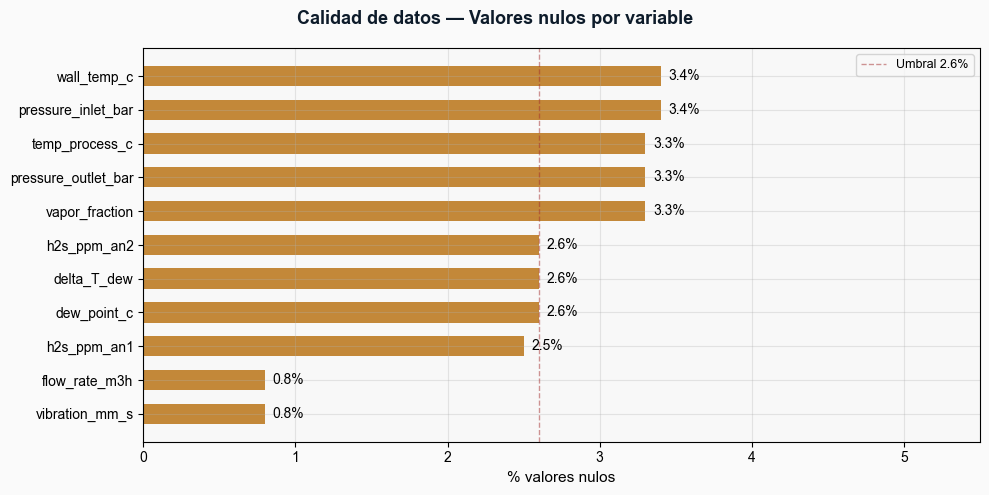

✓ fig01a_nulls.png


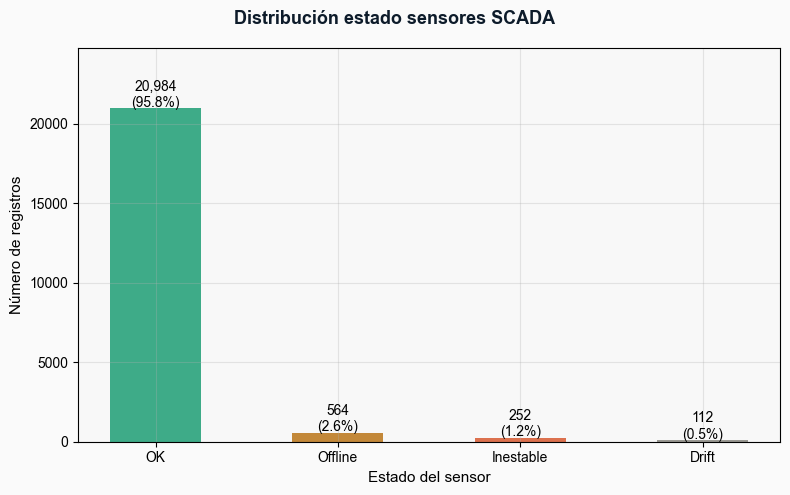

✓ fig01b_sensor_status.png


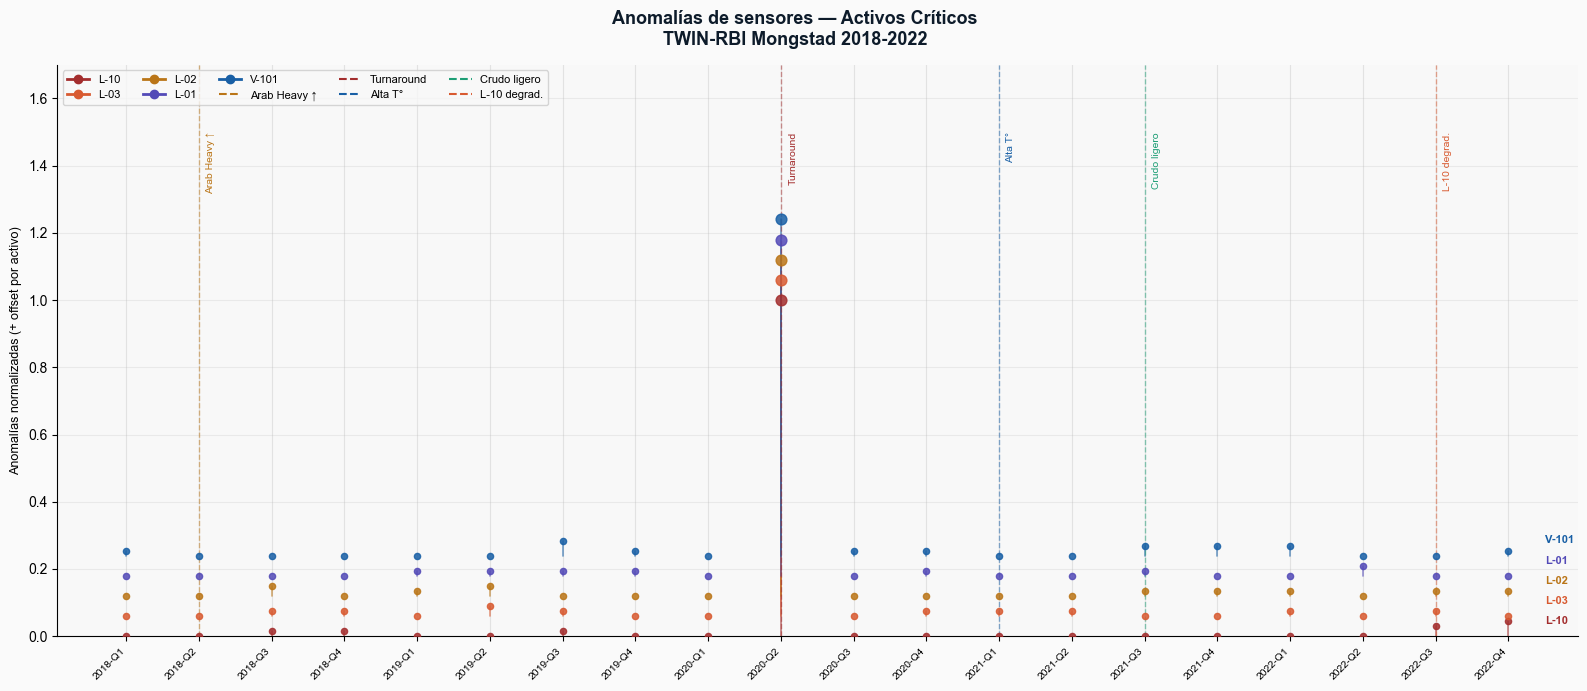

✓ fig01c_timeline.png guardado


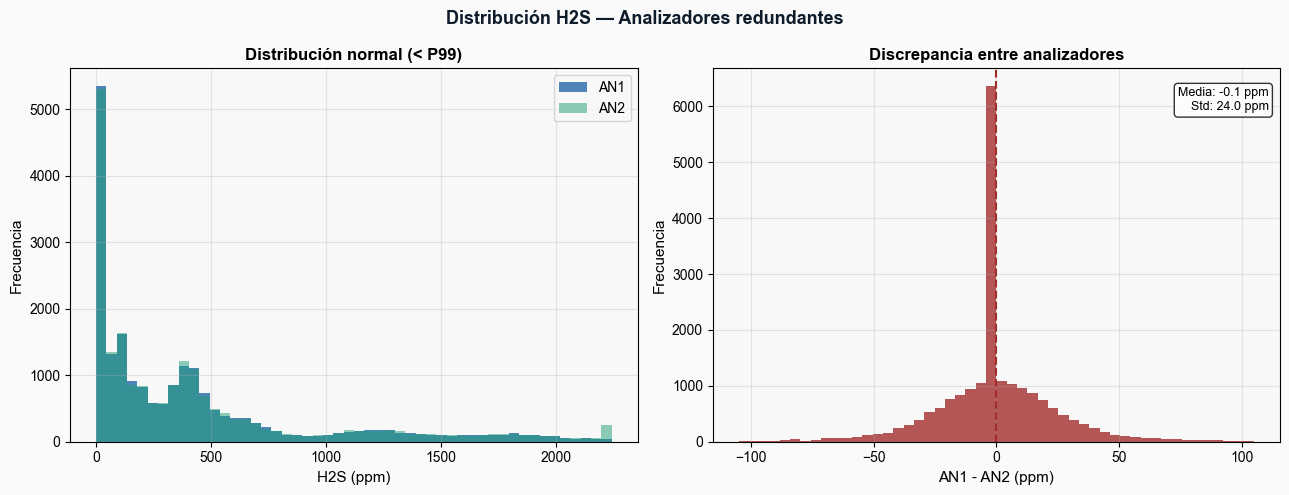

✓ fig01d_h2s_quality.png


In [27]:
# ── Figura 1: Valores nulos ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Calidad de datos — Valores nulos por variable',
             fontsize=13, fontweight='bold', color=COLORS['navy'])

nulls = df_scada.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=True)
pct   = (nulls / len(df_scada) * 100).round(1)

bars = ax.barh(nulls.index, pct.values, color=COLORS['amber'],
               alpha=0.85, height=0.6)
for bar, val in zip(bars, pct.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
ax.set_xlabel('% valores nulos', fontsize=11)
ax.set_xlim(0, 5.5)
ax.axvline(2.6, color=COLORS['red'], linestyle='--',
           linewidth=1, alpha=0.5, label='Umbral 2.6%')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../assets/fig01a_nulls.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig01a_nulls.png")

# ── Figura 2: Estado sensores ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Distribución estado sensores SCADA',
             fontsize=13, fontweight='bold', color=COLORS['navy'])

status_counts = df_scada['sensor_status'].map(status_map).value_counts()
colors_st = [COLORS['teal'], COLORS['amber'], COLORS['coral'], COLORS['gray']]
bars = ax.bar(status_counts.index, status_counts.values,
              color=colors_st[:len(status_counts)], alpha=0.85, width=0.5)
for bar, val in zip(bars, status_counts.values):
    pct_val = val / len(df_scada) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}\n({pct_val:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Número de registros', fontsize=11)
ax.set_ylim(0, status_counts.max() * 1.18)
ax.set_xlabel('Estado del sensor', fontsize=11)
plt.tight_layout()
plt.savefig('../assets/fig01b_sensor_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig01b_sensor_status.png")

# ── Figura 3: Timeline anomalías — líneas por activo ─────
# ── Figura 3: Timeline anomalías — todos juntos normalizados ─────
# ── Figura 3: Lollipop anomalías — activos críticos ──────
criticos = ['L-10', 'L-03', 'L-02', 'L-01', 'V-101']

df_anom = df_scada[df_scada['sensor_status'] > 0].copy()
df_anom['year_q'] = df_anom['date'].dt.year.astype(str) + '-Q' + \
                    df_anom['date'].dt.quarter.astype(str)
all_q = sorted(df_anom['year_q'].unique())
q_idx = {q: i for i, q in enumerate(all_q)}

colors_crit = {
    'L-10': COLORS['red'],
    'L-03': COLORS['coral'],
    'L-02': COLORS['amber'],
    'L-01': COLORS['purple'],
    'V-101': COLORS['blue'],
}

eventos = {
    '2018-Q2': ('Arab Heavy ↑', COLORS['amber']),
    '2020-Q2': ('Turnaround',   COLORS['red']),
    '2021-Q1': ('Alta T°',      COLORS['blue']),
    '2021-Q3': ('Crudo ligero', COLORS['teal']),
    '2022-Q3': ('L-10 degrad.', COLORS['coral']),
}

# Offset vertical por activo para que no se pisen
offsets = {'L-10': 0, 'L-03': 0.06, 'L-02': 0.12,
           'L-01': 0.18, 'V-101': 0.24}

fig, ax = plt.subplots(figsize=(16, 7))
fig.suptitle('Anomalías de sensores — Activos Críticos\nTWIN-RBI Mongstad 2018-2022',
             fontsize=13, fontweight='bold', color=COLORS['navy'])

for activo in criticos:
    color  = colors_crit[activo]
    offset = offsets[activo]

    sub  = df_anom[df_anom['line_id']==activo].groupby('year_q').size()
    full = pd.Series(0.0, index=range(len(all_q)))
    for q, v in sub.items():
        if q in q_idx:
            full[q_idx[q]] = float(v)

    vmax      = full.values.max()
    full_norm = (full / vmax + offset) if vmax > 0 else full + offset

    for xi, yi in enumerate(full_norm.values):
        base = offset
        # Línea vertical (palo)
        ax.plot([xi, xi], [base, yi],
                color=color, lw=1.2, alpha=0.6, solid_capstyle='round')
        # Círculo (cabeza)
        size = 60 if yi > base + 0.05 else 20
        ax.scatter(xi, yi, color=color, s=size,
                   zorder=5, alpha=0.85)

    # Etiqueta activo al final
    ax.text(len(all_q) - 0.5, offset + 0.03, activo,
            color=color, fontsize=8, fontweight='bold', va='bottom')

# Eventos
for q, (label, ev_color) in eventos.items():
    if q in q_idx:
        ax.axvline(q_idx[q], color=ev_color, lw=1.0,
                   linestyle='--', alpha=0.5)
        ax.text(q_idx[q] + 0.1, 1.5, label,
                color=ev_color, fontsize=7.5,
                rotation=90, va='top')

ax.set_xticks(range(len(all_q)))
ax.set_xticklabels(all_q, rotation=45, ha='right', fontsize=7.5)
ax.set_ylabel('Anomalías normalizadas (+ offset por activo)', fontsize=9)
ax.set_ylim(0, 1.7)
ax.set_facecolor('#F8F8F8')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# Leyenda activos
from matplotlib.lines import Line2D
leg_activos = [Line2D([0],[0], color=colors_crit[a], lw=2,
                      marker='o', ms=6, label=a) for a in criticos]
leg_eventos = [Line2D([0],[0], color=c, lw=1.5, ls='--', label=l)
               for q,(l,c) in eventos.items()]
ax.legend(handles=leg_activos + leg_eventos,
          fontsize=8, loc='upper left', ncol=5, framealpha=0.8)

plt.tight_layout()
plt.savefig('../assets/fig01c_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig01c_timeline.png guardado")

# ── Figura 4: H2S distribución limpia ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución H2S — Analizadores redundantes',
             fontsize=13, fontweight='bold', color=COLORS['navy'])

df_ok = df_scada[df_scada['sensor_status'] == 0]

# Panel izq — distribución sin outliers (P99)
ax = axes[0]
p99 = df_ok['h2s_ppm_an1'].quantile(0.99)
h2s_clean = df_ok['h2s_ppm_an1'].dropna()
h2s_clean = h2s_clean[h2s_clean <= p99]
ax.hist(h2s_clean, bins=50, color=COLORS['blue'], alpha=0.75, label='AN1')
ax.hist(df_ok['h2s_ppm_an2'].dropna().clip(upper=p99),
        bins=50, color=COLORS['teal'], alpha=0.5, label='AN2')
ax.set_xlabel('H2S (ppm)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución normal (< P99)', fontweight='bold')
ax.legend()

# Panel der — discrepancia entre analizadores
ax2 = axes[1]
diff = (df_ok['h2s_ppm_an1'] - df_ok['h2s_ppm_an2']).dropna()
diff_clean = diff[diff.abs() <= diff.abs().quantile(0.99)]
ax2.hist(diff_clean, bins=50, color=COLORS['red'], alpha=0.8)
ax2.axvline(0, color=COLORS['red'], linestyle='--', linewidth=1.5)
ax2.set_xlabel('AN1 - AN2 (ppm)', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Discrepancia entre analizadores', fontweight='bold')
ax2.text(0.98, 0.95, f'Media: {diff_clean.mean():.1f} ppm\nStd: {diff_clean.std():.1f} ppm',
         transform=ax2.transAxes, ha='right', va='top',
         fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../assets/fig01d_h2s_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig01d_h2s_quality.png")

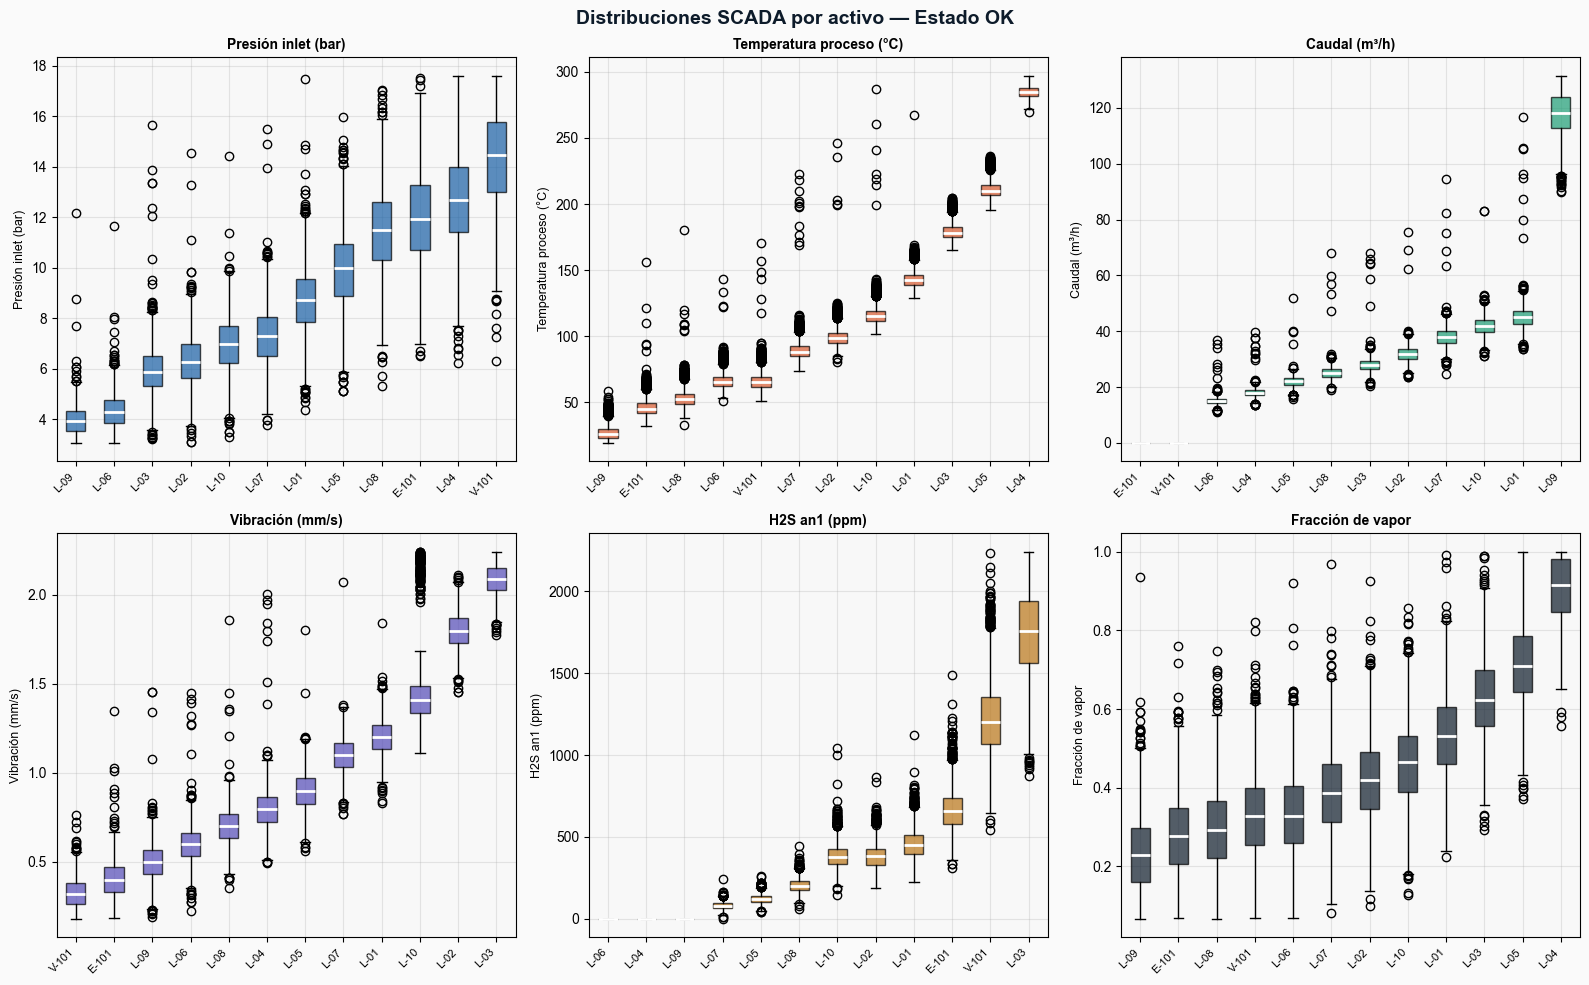

✓ fig02_scada_distributions.png guardado


In [8]:
# Filtrar solo datos OK
df_ok = df_scada[df_scada['sensor_status'] == 0].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones SCADA por activo — Estado OK',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

variables = [
    ('pressure_inlet_bar', 'Presión inlet (bar)',      COLORS['blue']),
    ('temp_process_c',     'Temperatura proceso (°C)', COLORS['coral']),
    ('flow_rate_m3h',      'Caudal (m³/h)',            COLORS['teal']),
    ('vibration_mm_s',     'Vibración (mm/s)',         COLORS['purple']),
    ('h2s_ppm_an1',        'H2S an1 (ppm)',            COLORS['amber']),
    ('vapor_fraction',     'Fracción de vapor',        COLORS['navy']),
]

for ax, (col, label, color) in zip(axes.flat, variables):
    # Eliminar outliers extremos para visualización
    p1, p99 = df_ok[col].quantile(0.01), df_ok[col].quantile(0.99)
    data = df_ok[(df_ok[col] >= p1) & (df_ok[col] <= p99)]

    # Boxplot por activo
    activos = data.groupby('line_id')[col].median().sort_values().index
    data_grouped = [data[data['line_id'] == a][col].dropna().values
                    for a in activos]

    bp = ax.boxplot(data_grouped, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticklabels(activos, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../assets/fig02_scada_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig02_scada_distributions.png guardado")

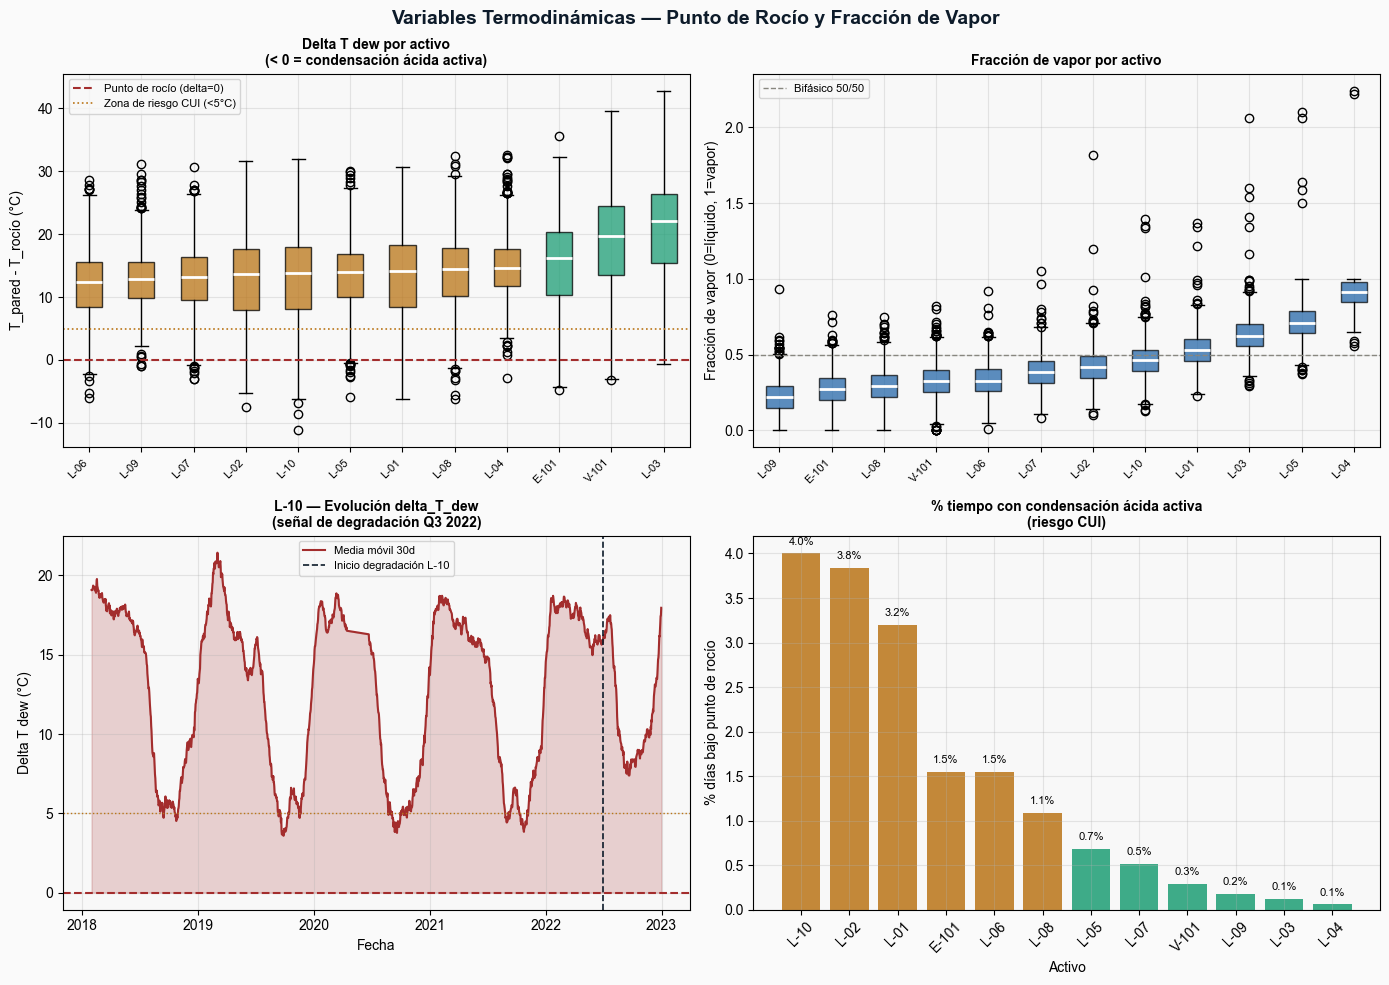

✓ fig03_thermodynamics.png guardado


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variables Termodinámicas — Punto de Rocío y Fracción de Vapor',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

df_ok = df_scada[df_scada['sensor_status'] == 0].copy()

# ── Panel 1: delta_T_dew por activo ──────────────────────
ax1 = axes[0, 0]
order = df_ok.groupby('line_id')['delta_T_dew'].median().sort_values().index
data_dew = [df_ok[df_ok['line_id'] == a]['delta_T_dew'].dropna().values
            for a in order]
bp = ax1.boxplot(data_dew, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for i, patch in enumerate(bp['boxes']):
    median_val = df_ok[df_ok['line_id'] == order[i]]['delta_T_dew'].median()
    patch.set_facecolor(COLORS['red'] if median_val < 5 else
                        COLORS['amber'] if median_val < 15 else COLORS['teal'])
    patch.set_alpha(0.75)
ax1.axhline(0, color=COLORS['red'], linestyle='--', linewidth=1.5,
            label='Punto de rocío (delta=0)')
ax1.axhline(5, color=COLORS['amber'], linestyle=':', linewidth=1.2,
            label='Zona de riesgo CUI (<5°C)')
ax1.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('T_pared - T_rocío (°C)', fontsize=10)
ax1.set_title('Delta T dew por activo\n(< 0 = condensación ácida activa)',
              fontweight='bold', fontsize=10)
ax1.legend(fontsize=8)

# ── Panel 2: fracción vapor por activo ───────────────────
ax2 = axes[0, 1]
order_vap = df_ok.groupby('line_id')['vapor_fraction'].median().sort_values().index
data_vap = [df_ok[df_ok['line_id'] == a]['vapor_fraction'].dropna().values
            for a in order_vap]
bp2 = ax2.boxplot(data_vap, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch in bp2['boxes']:
    patch.set_facecolor(COLORS['blue'])
    patch.set_alpha(0.7)
ax2.axhline(0.5, color=COLORS['gray'], linestyle='--', linewidth=1,
            label='Bifásico 50/50')
ax2.set_xticklabels(order_vap, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Fracción de vapor (0=líquido, 1=vapor)', fontsize=10)
ax2.set_title('Fracción de vapor por activo', fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)

# ── Panel 3: delta_T_dew timeline L-10 ───────────────────
ax3 = axes[1, 0]
l10 = df_ok[df_ok['line_id'] == 'L-10'].copy()
ax3.plot(l10['date'], l10['delta_T_dew'].rolling(30).mean(),
         color=COLORS['red'], linewidth=1.5, label='Media móvil 30d')
ax3.fill_between(l10['date'],
                 l10['delta_T_dew'].rolling(30).mean(),
                 alpha=0.2, color=COLORS['red'])
ax3.axhline(0, color=COLORS['red'], linestyle='--', linewidth=1.5)
ax3.axhline(5, color=COLORS['amber'], linestyle=':', linewidth=1)
ax3.axvline(pd.Timestamp('2022-07-01'), color=COLORS['navy'],
            linestyle='--', linewidth=1.2, label='Inicio degradación L-10')
ax3.set_xlabel('Fecha')
ax3.set_ylabel('Delta T dew (°C)')
ax3.set_title('L-10 — Evolución delta_T_dew\n(señal de degradación Q3 2022)',
              fontweight='bold', fontsize=10)
ax3.legend(fontsize=8)

# ── Panel 4: % días bajo punto rocío por activo ──────────
ax4 = axes[1, 1]
pct_below = df_ok.groupby('line_id').apply(
    lambda x: (x['delta_T_dew'] < 0).mean() * 100
).sort_values(ascending=False)
colors_bar = [COLORS['red'] if v > 5 else
              COLORS['amber'] if v > 1 else COLORS['teal']
              for v in pct_below.values]
bars = ax4.bar(pct_below.index, pct_below.values,
               color=colors_bar, alpha=0.85)
for bar, val in zip(bars, pct_below.values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=8)
ax4.set_ylabel('% días bajo punto de rocío', fontsize=10)
ax4.set_xlabel('Activo')
ax4.set_title('% tiempo con condensación ácida activa\n(riesgo CUI)',
              fontweight='bold', fontsize=10)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../assets/fig03_thermodynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig03_thermodynamics.png guardado")

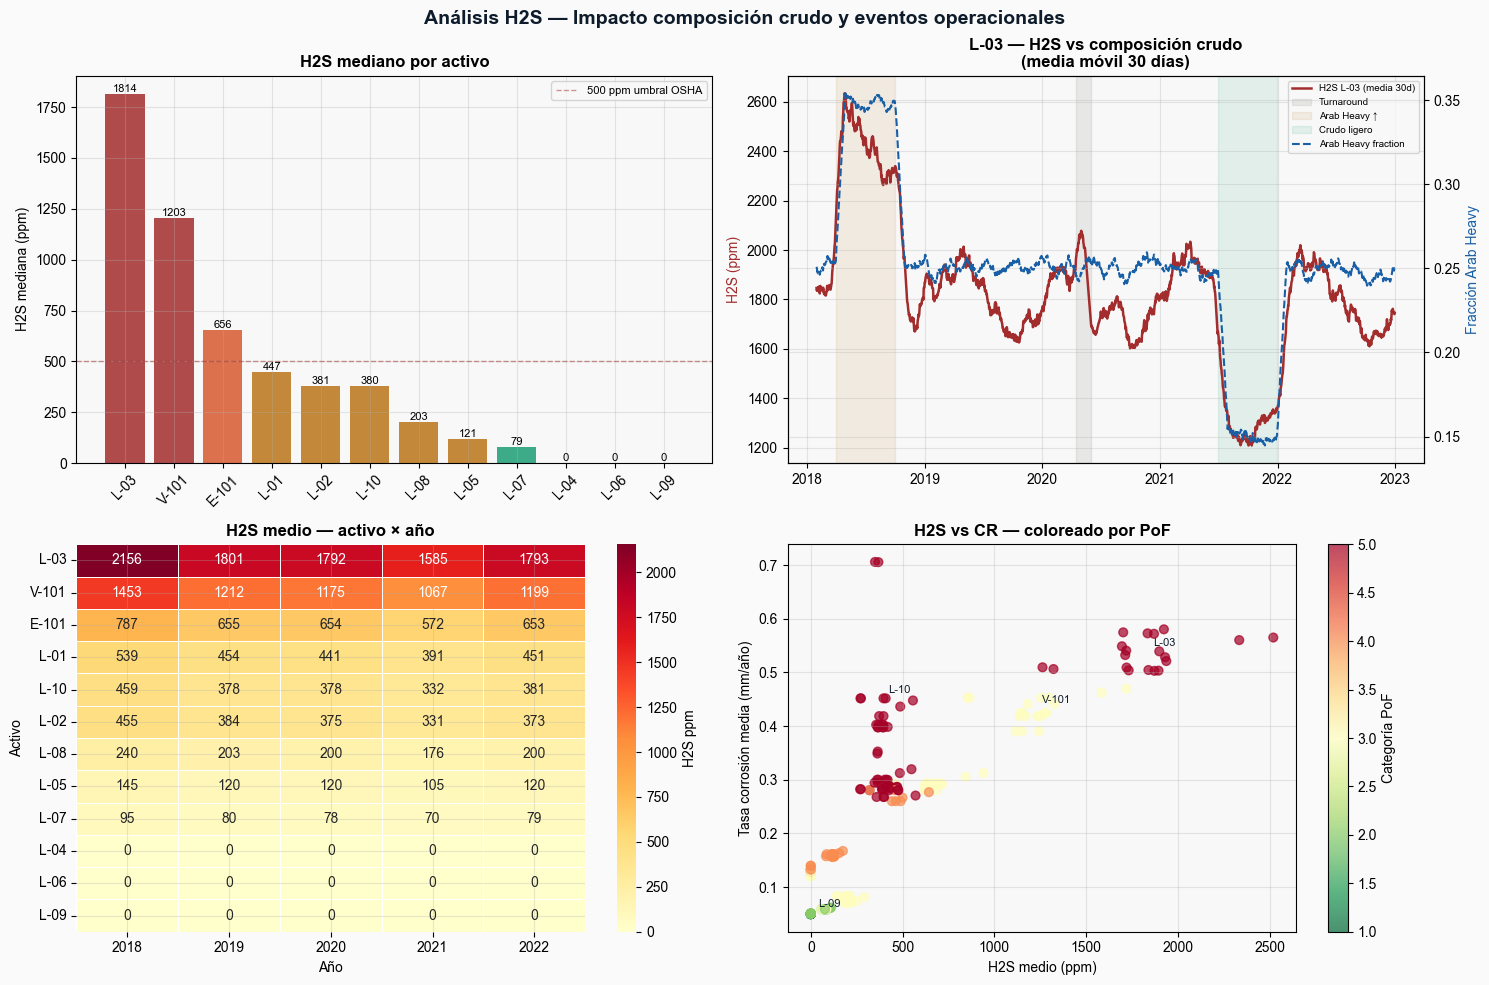

✓ fig04_h2s_analysis.png guardado


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis H2S — Impacto composición crudo y eventos operacionales',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

df_ok = df_scada[df_scada['sensor_status'] == 0].copy()
df_ok['h2s_avg'] = df_ok[['h2s_ppm_an1','h2s_ppm_an2']].mean(axis=1)
df_ok['year']    = df_ok['date'].dt.year

# ── Panel 1: H2S medio por activo ────────────────────────
ax1 = axes[0, 0]
h2s_by_asset = df_ok.groupby('line_id')['h2s_avg'].median().sort_values(ascending=False)
colors_h2s = [COLORS['red'] if v > 1000 else
              COLORS['coral'] if v > 500 else
              COLORS['amber'] if v > 100 else COLORS['teal']
              for v in h2s_by_asset.values]
bars = ax1.bar(h2s_by_asset.index, h2s_by_asset.values,
               color=colors_h2s, alpha=0.85)
for bar, val in zip(bars, h2s_by_asset.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{val:.0f}', ha='center', fontsize=8)
ax1.set_ylabel('H2S mediana (ppm)', fontsize=10)
ax1.set_title('H2S mediano por activo', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(500, color=COLORS['red'], linestyle='--',
            linewidth=1, alpha=0.5, label='500 ppm umbral OSHA')
ax1.legend(fontsize=8)

# ── Panel 2: H2S anual L-03 vs fracción Arab Heavy ───────
# ── Panel 2: H2S anual L-03 vs fracción Arab Heavy ───────
ax2 = axes[0, 1]
l03 = df_ok[df_ok['line_id'] == 'L-03'].copy()

# Resample incluyendo todos los días — interpolar gaps cortos
l03_all = df_scada[df_scada['line_id'] == 'L-03'].copy()
l03_all = l03_all.set_index('date').resample('D').mean(numeric_only=True)
l03_all['h2s_avg'] = l03_all[['h2s_ppm_an1','h2s_ppm_an2']].mean(axis=1)

# Media móvil 30 días — suaviza ruido y gaps
h2s_smooth = l03_all['h2s_avg'].interpolate(method='linear').rolling(30).mean()
arab_smooth = l03_all['arab_heavy_fraction'].interpolate(method='linear').rolling(30).mean()

ax2b = ax2.twinx()
ax2.plot(h2s_smooth.index, h2s_smooth.values,
         color=COLORS['red'], linewidth=1.8, label='H2S L-03 (media 30d)')
ax2b.plot(arab_smooth.index, arab_smooth.values,
          color=COLORS['blue'], linewidth=1.5,
          linestyle='--', label='Arab Heavy fraction')

# Marcar turnaround
ax2.axvspan(pd.Timestamp('2020-04-15'), pd.Timestamp('2020-05-31'),
            alpha=0.15, color=COLORS['gray'], label='Turnaround')
ax2.axvspan(pd.Timestamp('2018-04-01'), pd.Timestamp('2018-09-30'),
            alpha=0.1, color=COLORS['amber'], label='Arab Heavy ↑')
ax2.axvspan(pd.Timestamp('2021-07-01'), pd.Timestamp('2021-12-31'),
            alpha=0.1, color=COLORS['teal'], label='Crudo ligero')

ax2.set_ylabel('H2S (ppm)', color=COLORS['red'], fontsize=10)
ax2b.set_ylabel('Fracción Arab Heavy', color=COLORS['blue'], fontsize=10)
ax2.set_title('L-03 — H2S vs composición crudo\n(media móvil 30 días)',
              fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=7, loc='upper right')

# ── Panel 3: H2S heatmap activo × año ────────────────────
ax3 = axes[1, 0]
h2s_pivot = df_ok.groupby(['line_id','year'])['h2s_avg'].mean().unstack()
h2s_pivot = h2s_pivot.sort_values(by=2022, ascending=False)
sns.heatmap(h2s_pivot, ax=ax3, cmap='YlOrRd',
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label':'H2S ppm'})
ax3.set_title('H2S medio — activo × año', fontweight='bold')
ax3.set_xlabel('Año')
ax3.set_ylabel('Activo')

# ── Panel 4: H2S vs corrosion rate (features dataset) ────
ax4 = axes[1, 1]
sc = ax4.scatter(df_feat['h2s_mean'], df_feat['cr_mean'],
                 c=df_feat['pof_category'], cmap='RdYlGn_r',
                 s=40, alpha=0.7, vmin=1, vmax=5)
plt.colorbar(sc, ax=ax4, label='Categoría PoF')
ax4.set_xlabel('H2S medio (ppm)', fontsize=10)
ax4.set_ylabel('Tasa corrosión media (mm/año)', fontsize=10)
ax4.set_title('H2S vs CR — coloreado por PoF', fontweight='bold')

# Anotar activos extremos
for line in ['L-03', 'L-10', 'V-101', 'L-09']:
    sub = df_feat[df_feat['line_id'] == line]
    if len(sub) > 0:
        ax4.annotate(line,
                     xy=(sub['h2s_mean'].mean(), sub['cr_mean'].mean()),
                     fontsize=8, color=COLORS['navy'],
                     xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../assets/fig04_h2s_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig04_h2s_analysis.png guardado")

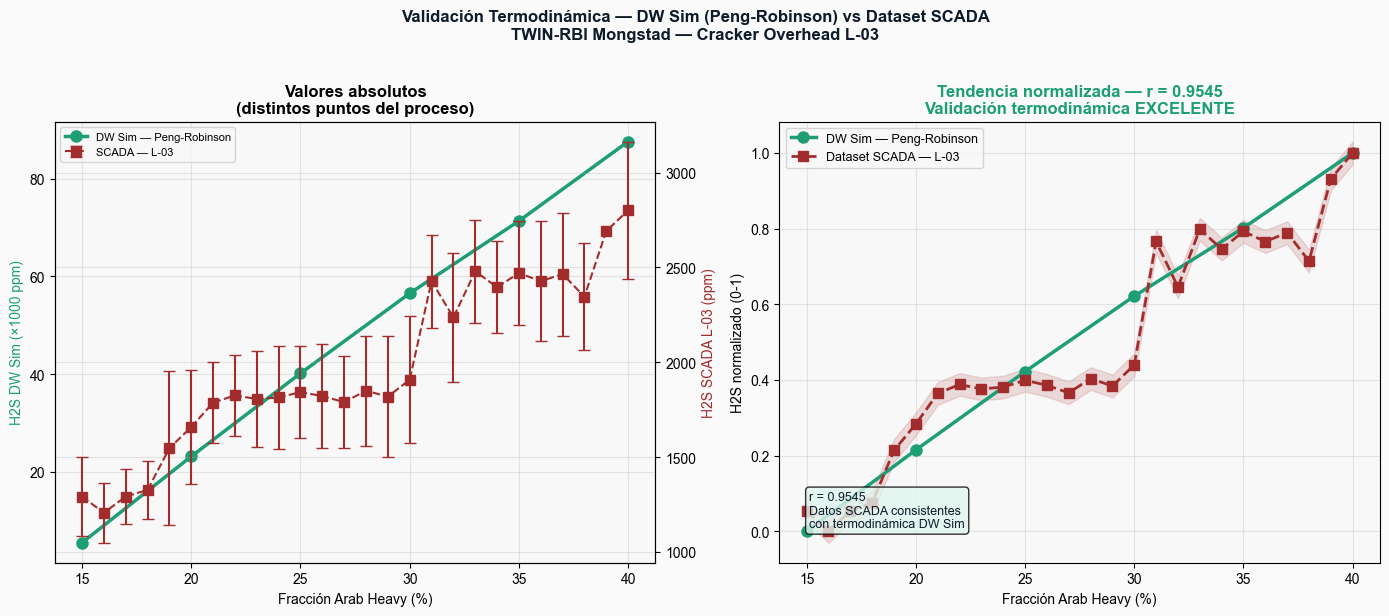

✓ fig05_dwsim_validation.png guardado  —  r = 0.9545  EXCELENTE


In [11]:
# Datos DW Sim — modelo Peng-Robinson
dwsim_data = {
    'arab_heavy_fraction': [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    'h2s_ppm_dwsim':       [5491, 23156, 40161, 56546, 71352, 87612]
}
df_dwsim = pd.DataFrame(dwsim_data)

# SCADA L-03
df_ok = df_scada[df_scada['sensor_status'] == 0].copy()
df_l03 = df_ok[df_ok['line_id'] == 'L-03'].copy()
df_l03['h2s_avg'] = df_l03[['h2s_ppm_an1','h2s_ppm_an2']].mean(axis=1)
df_l03['arab_bin'] = df_l03['arab_heavy_fraction'].round(2)
df_grp = df_l03.groupby('arab_bin').agg(
    h2s_mean=('h2s_avg','mean'),
    h2s_std=('h2s_avg','std'),
    n=('h2s_avg','count')
).reset_index()

df_grp_filt = df_grp[(df_grp['arab_bin'] >= 0.15) &
                     (df_grp['arab_bin'] <= 0.40)].copy()
df_grp_filt['h2s_norm'] = ((df_grp_filt['h2s_mean'] - df_grp_filt['h2s_mean'].min()) /
                            (df_grp_filt['h2s_mean'].max() - df_grp_filt['h2s_mean'].min()))
df_dwsim['h2s_norm'] = ((df_dwsim['h2s_ppm_dwsim'] - df_dwsim['h2s_ppm_dwsim'].min()) /
                         (df_dwsim['h2s_ppm_dwsim'].max() - df_dwsim['h2s_ppm_dwsim'].min()))

from scipy.interpolate import interp1d
f_dw = interp1d(df_dwsim['arab_heavy_fraction'], df_dwsim['h2s_norm'], kind='linear')
dw_interp = f_dw(df_grp_filt['arab_bin'])
corr = np.corrcoef(df_grp_filt['h2s_norm'], dw_interp)[0,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Validación Termodinámica — DW Sim (Peng-Robinson) vs Dataset SCADA\n'
             'TWIN-RBI Mongstad — Cracker Overhead L-03',
             fontsize=12, fontweight='bold', color=COLORS['navy'], y=1.02)

# ── Panel 1: Valores absolutos ────────────────────────────
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(df_dwsim['arab_heavy_fraction']*100,
         df_dwsim['h2s_ppm_dwsim']/1000,
         'o-', color=COLORS['teal'], lw=2.5, ms=8,
         label='DW Sim — Peng-Robinson')
ax1b.errorbar(df_grp_filt['arab_bin']*100,
              df_grp_filt['h2s_mean'],
              yerr=df_grp_filt['h2s_std'],
              fmt='s--', color=COLORS['red'], ms=7,
              capsize=4, lw=1.5, label='SCADA — L-03')
ax1.set_xlabel('Fracción Arab Heavy (%)', fontsize=10)
ax1.set_ylabel('H2S DW Sim (×1000 ppm)', color=COLORS['teal'], fontsize=10)
ax1b.set_ylabel('H2S SCADA L-03 (ppm)', color=COLORS['red'], fontsize=10)
ax1.set_title('Valores absolutos\n(distintos puntos del proceso)', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# ── Panel 2: Tendencias normalizadas ──────────────────────
ax2 = axes[1]
ax2.plot(df_dwsim['arab_heavy_fraction']*100,
         df_dwsim['h2s_norm'],
         'o-', color=COLORS['teal'], lw=2.5, ms=8,
         label='DW Sim — Peng-Robinson')
ax2.plot(df_grp_filt['arab_bin']*100,
         df_grp_filt['h2s_norm'],
         's--', color=COLORS['red'], lw=2, ms=7,
         label='Dataset SCADA — L-03')
ax2.fill_between(df_grp_filt['arab_bin']*100,
                 df_grp_filt['h2s_norm'] - 0.03,
                 df_grp_filt['h2s_norm'] + 0.03,
                 alpha=0.15, color=COLORS['red'])
ax2.set_xlabel('Fracción Arab Heavy (%)', fontsize=10)
ax2.set_ylabel('H2S normalizado (0-1)', fontsize=10)
status = 'EXCELENTE' if corr > 0.95 else 'BUENA' if corr > 0.85 else 'ACEPTABLE'
color_title = COLORS['teal'] if corr > 0.95 else COLORS['amber']
ax2.set_title(f'Tendencia normalizada — r = {corr:.4f}\nValidación termodinámica {status}',
              fontweight='bold', color=color_title)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.text(0.05, 0.08,
         f'r = {corr:.4f}\nDatos SCADA consistentes\ncon termodinámica DW Sim',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#E1F5EE', alpha=0.8),
         color=COLORS['navy'])

plt.tight_layout()
plt.savefig('../assets/fig05_dwsim_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ fig05_dwsim_validation.png guardado  —  r = {corr:.4f}  {status}")

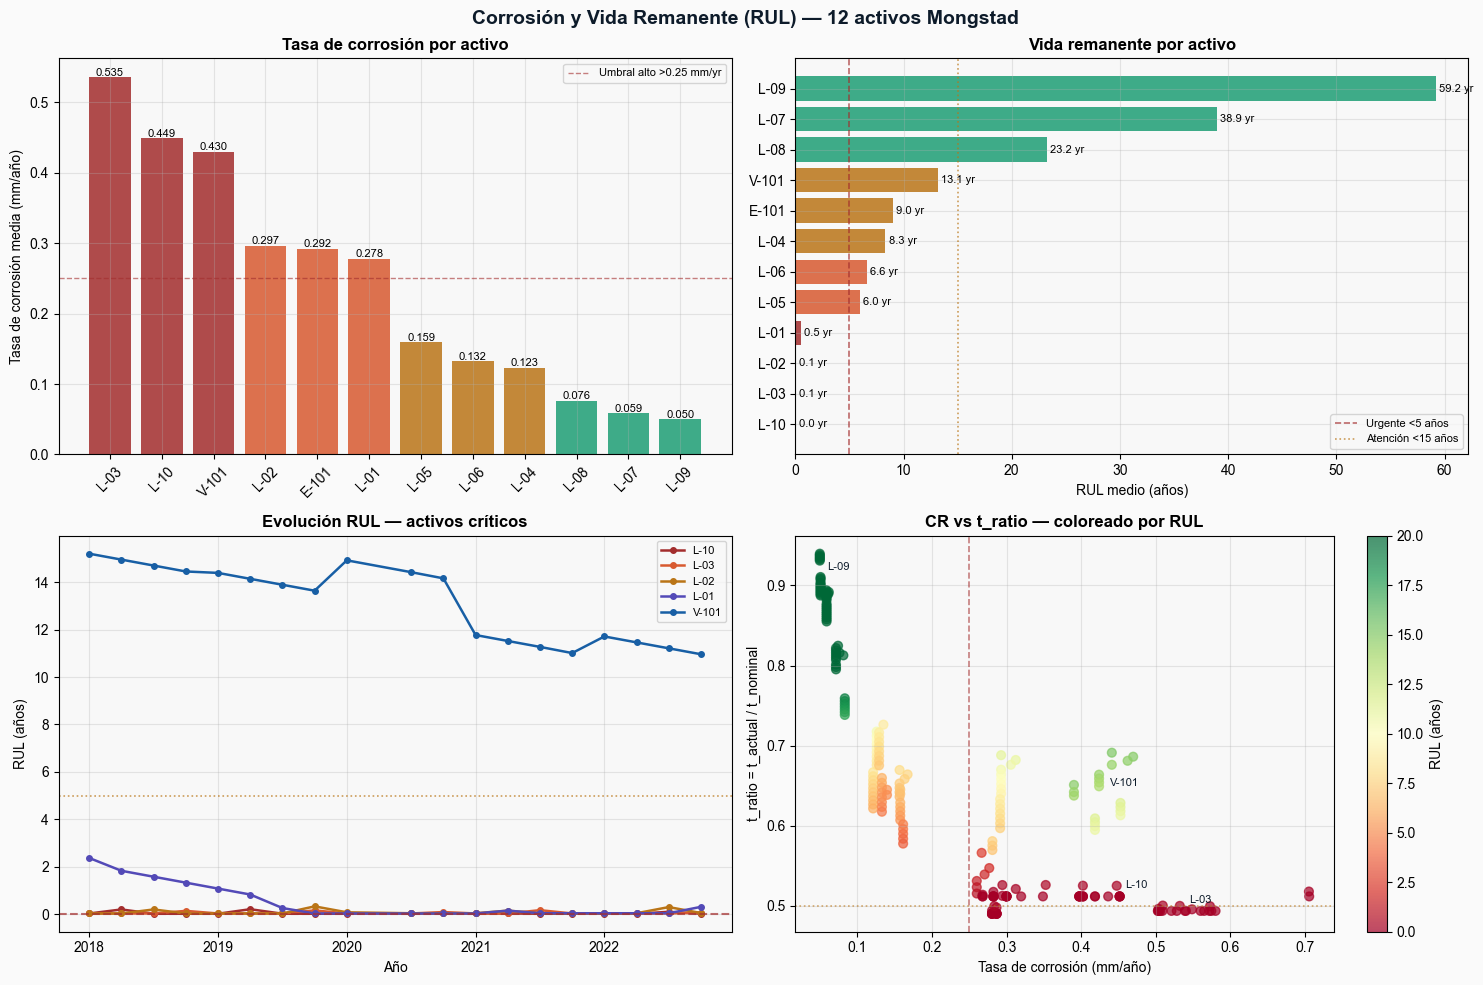

✓ fig06_corrosion_rul.png guardado


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Corrosión y Vida Remanente (RUL) — 12 activos Mongstad',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

# ── Panel 1: CR media por activo ─────────────────────────
ax1 = axes[0, 0]
cr_by_asset = df_feat.groupby('line_id')['cr_mean'].mean().sort_values(ascending=False)
colors_cr = [COLORS['red'] if v > 0.35 else
             COLORS['coral'] if v > 0.25 else
             COLORS['amber'] if v > 0.10 else COLORS['teal']
             for v in cr_by_asset.values]
bars = ax1.bar(cr_by_asset.index, cr_by_asset.values,
               color=colors_cr, alpha=0.85)
for bar, val in zip(bars, cr_by_asset.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=8)
ax1.set_ylabel('Tasa de corrosión media (mm/año)', fontsize=10)
ax1.set_title('Tasa de corrosión por activo', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(0.25, color=COLORS['red'], linestyle='--',
            linewidth=1, alpha=0.6, label='Umbral alto >0.25 mm/yr')
ax1.legend(fontsize=8)

# ── Panel 2: RUL por activo ───────────────────────────────
ax2 = axes[0, 1]
rul_by_asset = df_feat.groupby('line_id')['RUL_years'].mean().sort_values()
colors_rul = [COLORS['red'] if v < 3 else
              COLORS['coral'] if v < 8 else
              COLORS['amber'] if v < 15 else COLORS['teal']
              for v in rul_by_asset.values]
bars2 = ax2.barh(rul_by_asset.index, rul_by_asset.values,
                 color=colors_rul, alpha=0.85)
for bar, val in zip(bars2, rul_by_asset.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} yr', va='center', fontsize=8)
ax2.axvline(5, color=COLORS['red'], linestyle='--',
            linewidth=1.2, alpha=0.7, label='Urgente <5 años')
ax2.axvline(15, color=COLORS['amber'], linestyle=':',
            linewidth=1.2, alpha=0.7, label='Atención <15 años')
ax2.set_xlabel('RUL medio (años)', fontsize=10)
ax2.set_title('Vida remanente por activo', fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: Evolución RUL en el tiempo — activos críticos
ax3 = axes[1, 0]
criticos = ['L-10', 'L-03', 'L-02', 'L-01', 'V-101']
colors_line = [COLORS['red'], COLORS['coral'], COLORS['amber'],
               COLORS['purple'], COLORS['blue']]
for activo, color in zip(criticos, colors_line):
    sub = df_feat[df_feat['line_id'] == activo].copy()
    sub['period'] = sub['year'] + (sub['quarter']-1)/4
    ax3.plot(sub['period'], sub['RUL_years'],
             marker='o', ms=4, lw=1.8,
             color=color, label=activo)
ax3.axhline(0, color=COLORS['red'], linestyle='--', lw=1.5, alpha=0.7)
ax3.axhline(5, color=COLORS['amber'], linestyle=':', lw=1.2, alpha=0.7)
ax3.set_xlabel('Año', fontsize=10)
ax3.set_ylabel('RUL (años)', fontsize=10)
ax3.set_title('Evolución RUL — activos críticos',
              fontweight='bold')
ax3.legend(fontsize=8)

# ── Panel 4: t_ratio vs CR — mapa de riesgo físico ───────
ax4 = axes[1, 1]
sc = ax4.scatter(df_feat['cr_mean'], df_feat['t_ratio'],
                 c=df_feat['RUL_years'].clip(upper=20),
                 cmap='RdYlGn', s=40, alpha=0.7,
                 vmin=0, vmax=20)
plt.colorbar(sc, ax=ax4, label='RUL (años)')
ax4.axvline(0.25, color=COLORS['red'], linestyle='--',
            lw=1.2, alpha=0.6)
ax4.axhline(0.5, color=COLORS['amber'], linestyle=':',
            lw=1.2, alpha=0.6)
ax4.set_xlabel('Tasa de corrosión (mm/año)', fontsize=10)
ax4.set_ylabel('t_ratio = t_actual / t_nominal', fontsize=10)
ax4.set_title('CR vs t_ratio — coloreado por RUL',
              fontweight='bold')
for activo in ['L-10', 'L-03', 'V-101', 'L-09']:
    sub = df_feat[df_feat['line_id'] == activo]
    ax4.annotate(activo,
                 xy=(sub['cr_mean'].mean(), sub['t_ratio'].mean()),
                 fontsize=8, color=COLORS['navy'],
                 xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../assets/fig06_corrosion_rul.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig06_corrosion_rul.png guardado")

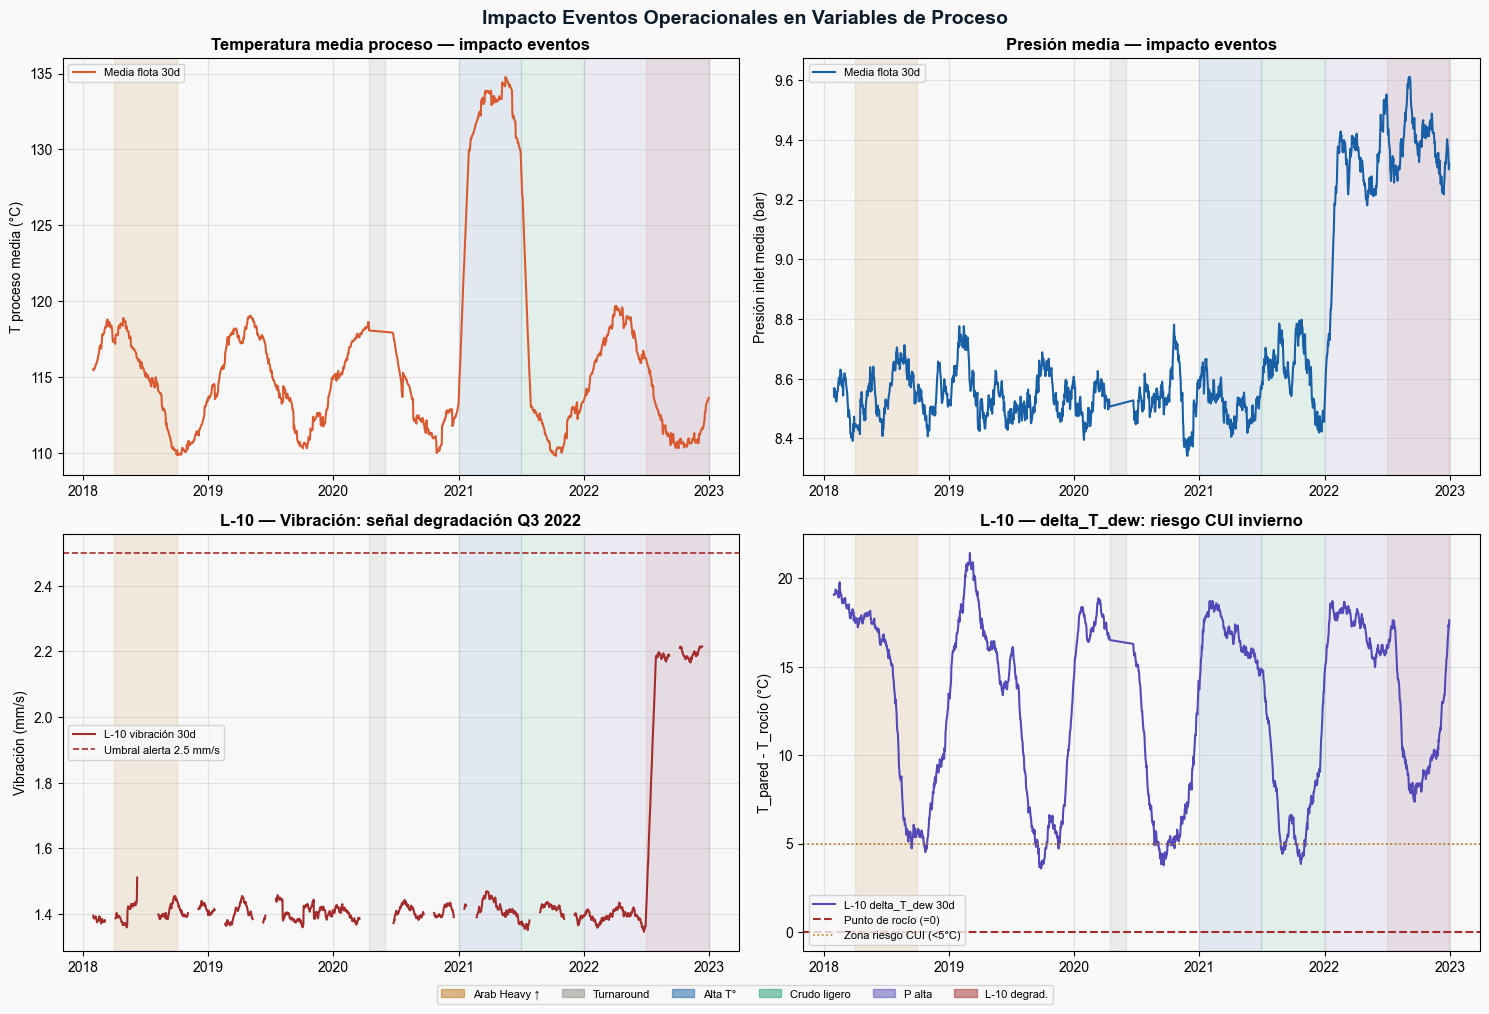

✓ fig07_operational_events.png guardado


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Impacto Eventos Operacionales en Variables de Proceso',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

df_ok = df_scada[df_scada['sensor_status'].isin([0,1])].copy()
df_ok['h2s_avg'] = df_ok[['h2s_ppm_an1','h2s_ppm_an2']].mean(axis=1)

# Franjas de eventos
eventos_span = [
    ('2018-04-01','2018-09-30', 'Arab Heavy ↑',  COLORS['amber'],  0.12),
    ('2020-04-15','2020-05-31', 'Turnaround',     COLORS['gray'],   0.12),
    ('2021-01-01','2021-06-30', 'Alta T°',        COLORS['blue'],   0.10),
    ('2021-07-01','2021-12-31', 'Crudo ligero',   COLORS['teal'],   0.10),
    ('2022-01-01','2022-12-31', 'P alta',         COLORS['purple'], 0.08),
    ('2022-07-01','2022-12-31', 'L-10 degrad.',   COLORS['red'],    0.08),
]

def add_event_spans(ax, y_max=None):
    for s, e, lbl, col, alpha in eventos_span:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=alpha, color=col)

# ── Panel 1: Temperatura proceso — todos activos media ───
ax1 = axes[0,0]
daily_T = df_ok.groupby('date')['temp_process_c'].mean().reset_index()
daily_T['T_roll'] = daily_T['temp_process_c'].rolling(30).mean()
add_event_spans(ax1)
ax1.plot(daily_T['date'], daily_T['T_roll'],
         color=COLORS['coral'], lw=1.5, label='Media flota 30d')
ax1.set_ylabel('T proceso media (°C)', fontsize=10)
ax1.set_title('Temperatura media proceso — impacto eventos',
              fontweight='bold')
ax1.legend(fontsize=8)

# ── Panel 2: Presión media ────────────────────────────────
ax2 = axes[0,1]
daily_P = df_ok.groupby('date')['pressure_inlet_bar'].mean().reset_index()
daily_P['P_roll'] = daily_P['pressure_inlet_bar'].rolling(30).mean()
add_event_spans(ax2)
ax2.plot(daily_P['date'], daily_P['P_roll'],
         color=COLORS['blue'], lw=1.5, label='Media flota 30d')
ax2.set_ylabel('Presión inlet media (bar)', fontsize=10)
ax2.set_title('Presión media — impacto eventos', fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: Vibración L-10 ───────────────────────────────
ax3 = axes[1,0]
l10_vib = df_ok[df_ok['line_id']=='L-10'][['date','vibration_mm_s']].copy()
l10_vib['vib_roll'] = l10_vib['vibration_mm_s'].rolling(30).mean()
add_event_spans(ax3)
ax3.plot(l10_vib['date'], l10_vib['vib_roll'],
         color=COLORS['red'], lw=1.5, label='L-10 vibración 30d')
ax3.axhline(2.5, color=COLORS['red'], linestyle='--',
            lw=1.2, label='Umbral alerta 2.5 mm/s')
ax3.set_ylabel('Vibración (mm/s)', fontsize=10)
ax3.set_title('L-10 — Vibración: señal degradación Q3 2022',
              fontweight='bold')
ax3.legend(fontsize=8)

# ── Panel 4: delta_T_dew L-10 ────────────────────────────
ax4 = axes[1,1]
l10_dew = df_ok[df_ok['line_id']=='L-10'][['date','delta_T_dew']].copy()
l10_dew['dew_roll'] = l10_dew['delta_T_dew'].rolling(30).mean()
add_event_spans(ax4)
ax4.plot(l10_dew['date'], l10_dew['dew_roll'],
         color=COLORS['purple'], lw=1.5, label='L-10 delta_T_dew 30d')
ax4.axhline(0, color=COLORS['red'], linestyle='--',
            lw=1.5, label='Punto de rocío (=0)')
ax4.axhline(5, color=COLORS['amber'], linestyle=':',
            lw=1.2, label='Zona riesgo CUI (<5°C)')
ax4.set_ylabel('T_pared - T_rocío (°C)', fontsize=10)
ax4.set_title('L-10 — delta_T_dew: riesgo CUI invierno',
              fontweight='bold')
ax4.legend(fontsize=8)

# Leyenda de eventos compartida
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, alpha=0.5, label=l)
                  for _,_,l,c,_ in eventos_span]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../assets/fig07_operational_events.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig07_operational_events.png guardado")

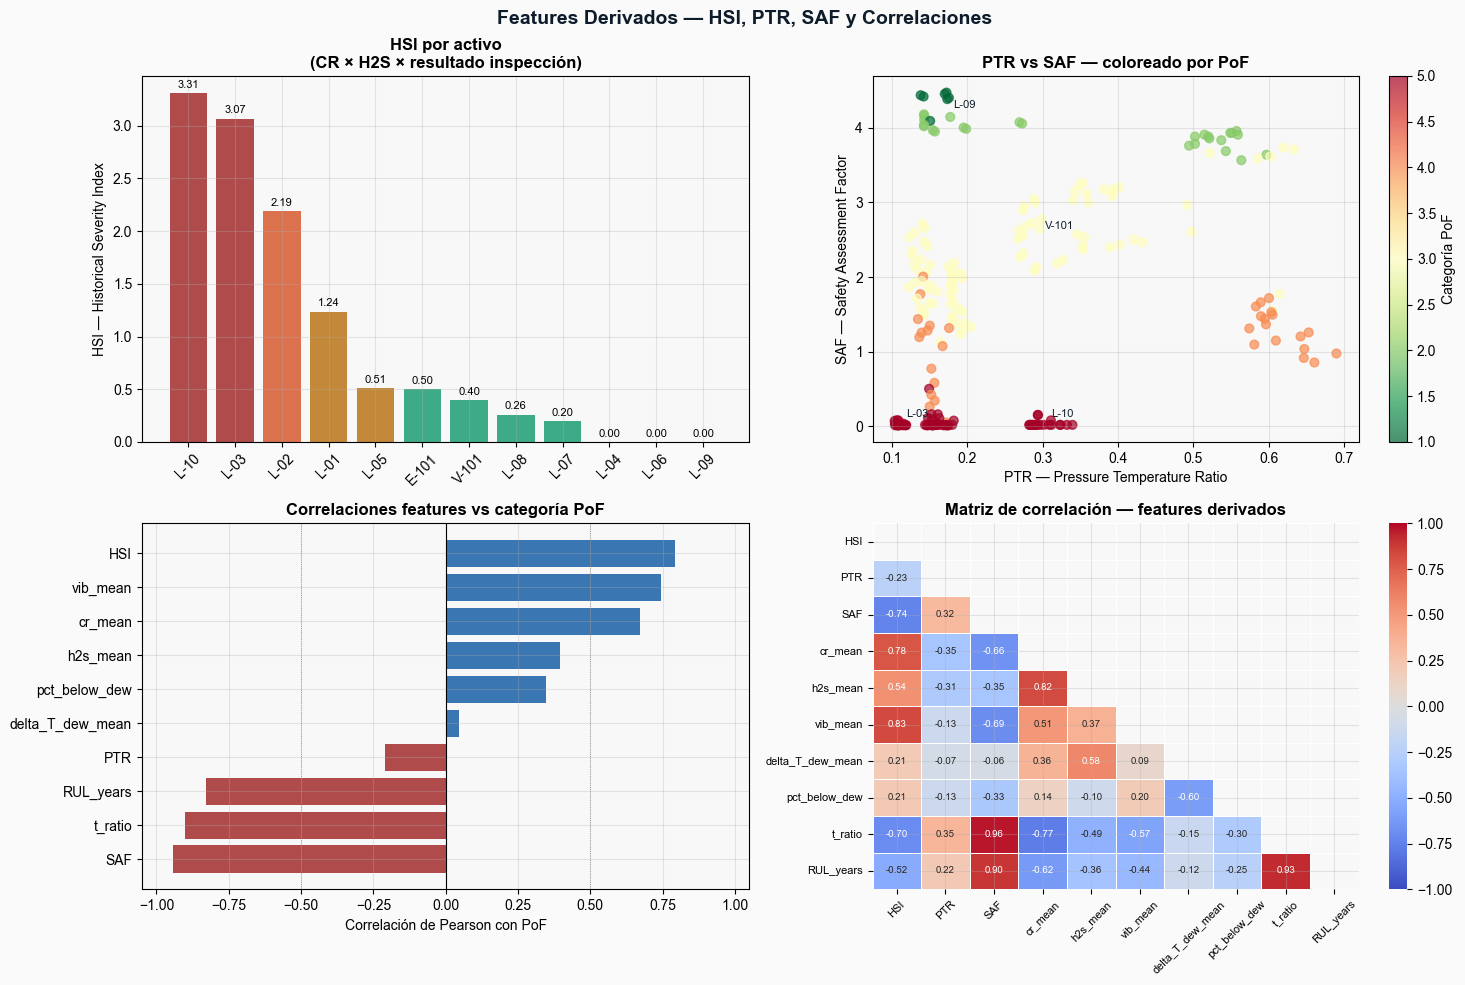

✓ fig08_engineered_features.png guardado


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Features Derivados — HSI, PTR, SAF y Correlaciones',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

# ── Panel 1: HSI por activo ───────────────────────────────
ax1 = axes[0,0]
hsi_by = df_feat.groupby('line_id')['HSI'].mean().sort_values(ascending=False)
colors_hsi = [COLORS['red'] if v > 3 else
              COLORS['coral'] if v > 1.5 else
              COLORS['amber'] if v > 0.5 else COLORS['teal']
              for v in hsi_by.values]
bars = ax1.bar(hsi_by.index, hsi_by.values, color=colors_hsi, alpha=0.85)
for bar, val in zip(bars, hsi_by.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=8)
ax1.set_ylabel('HSI — Historical Severity Index', fontsize=10)
ax1.set_title('HSI por activo\n(CR × H2S × resultado inspección)',
              fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# ── Panel 2: PTR vs SAF scatter ──────────────────────────
ax2 = axes[0,1]
sc = ax2.scatter(df_feat['PTR'], df_feat['SAF'],
                 c=df_feat['pof_category'],
                 cmap='RdYlGn_r', s=40, alpha=0.7,
                 vmin=1, vmax=5)
plt.colorbar(sc, ax=ax2, label='Categoría PoF')
ax2.set_xlabel('PTR — Pressure Temperature Ratio', fontsize=10)
ax2.set_ylabel('SAF — Safety Assessment Factor', fontsize=10)
ax2.set_title('PTR vs SAF — coloreado por PoF', fontweight='bold')
for activo in ['L-10', 'L-03', 'V-101', 'L-09']:
    sub = df_feat[df_feat['line_id'] == activo]
    ax2.annotate(activo,
                 xy=(sub['PTR'].mean(), sub['SAF'].mean()),
                 fontsize=8, color=COLORS['navy'],
                 xytext=(5,5), textcoords='offset points')

# ── Panel 3: Mapa de correlaciones features vs PoF ───────
ax3 = axes[1,0]
feat_cols = ['HSI','PTR','SAF','cr_mean','h2s_mean',
             'vib_mean','delta_T_dew_mean','pct_below_dew',
             't_ratio','RUL_years']
corr_pof = df_feat[feat_cols + ['pof_category']].corr()['pof_category'].drop('pof_category')
corr_pof = corr_pof.sort_values()
colors_corr = [COLORS['red'] if v < 0 else COLORS['blue']
               for v in corr_pof.values]
bars3 = ax3.barh(corr_pof.index, corr_pof.values,
                 color=colors_corr, alpha=0.85)
ax3.axvline(0, color='black', lw=0.8)
ax3.axvline(0.5, color=COLORS['gray'], lw=0.6, ls=':')
ax3.axvline(-0.5, color=COLORS['gray'], lw=0.6, ls=':')
ax3.set_xlabel('Correlación de Pearson con PoF', fontsize=10)
ax3.set_title('Correlaciones features vs categoría PoF',
              fontweight='bold')
ax3.set_xlim(-1.05, 1.05)

# ── Panel 4: Heatmap correlación features ─────────────────
ax4 = axes[1,1]
corr_matrix = df_feat[feat_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax4, mask=mask,
            cmap='coolwarm', center=0,
            annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size':7},
            vmin=-1, vmax=1)
ax4.set_title('Matriz de correlación — features derivados',
              fontweight='bold')
ax4.tick_params(axis='x', rotation=45, labelsize=8)
ax4.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../assets/fig08_engineered_features.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig08_engineered_features.png guardado")

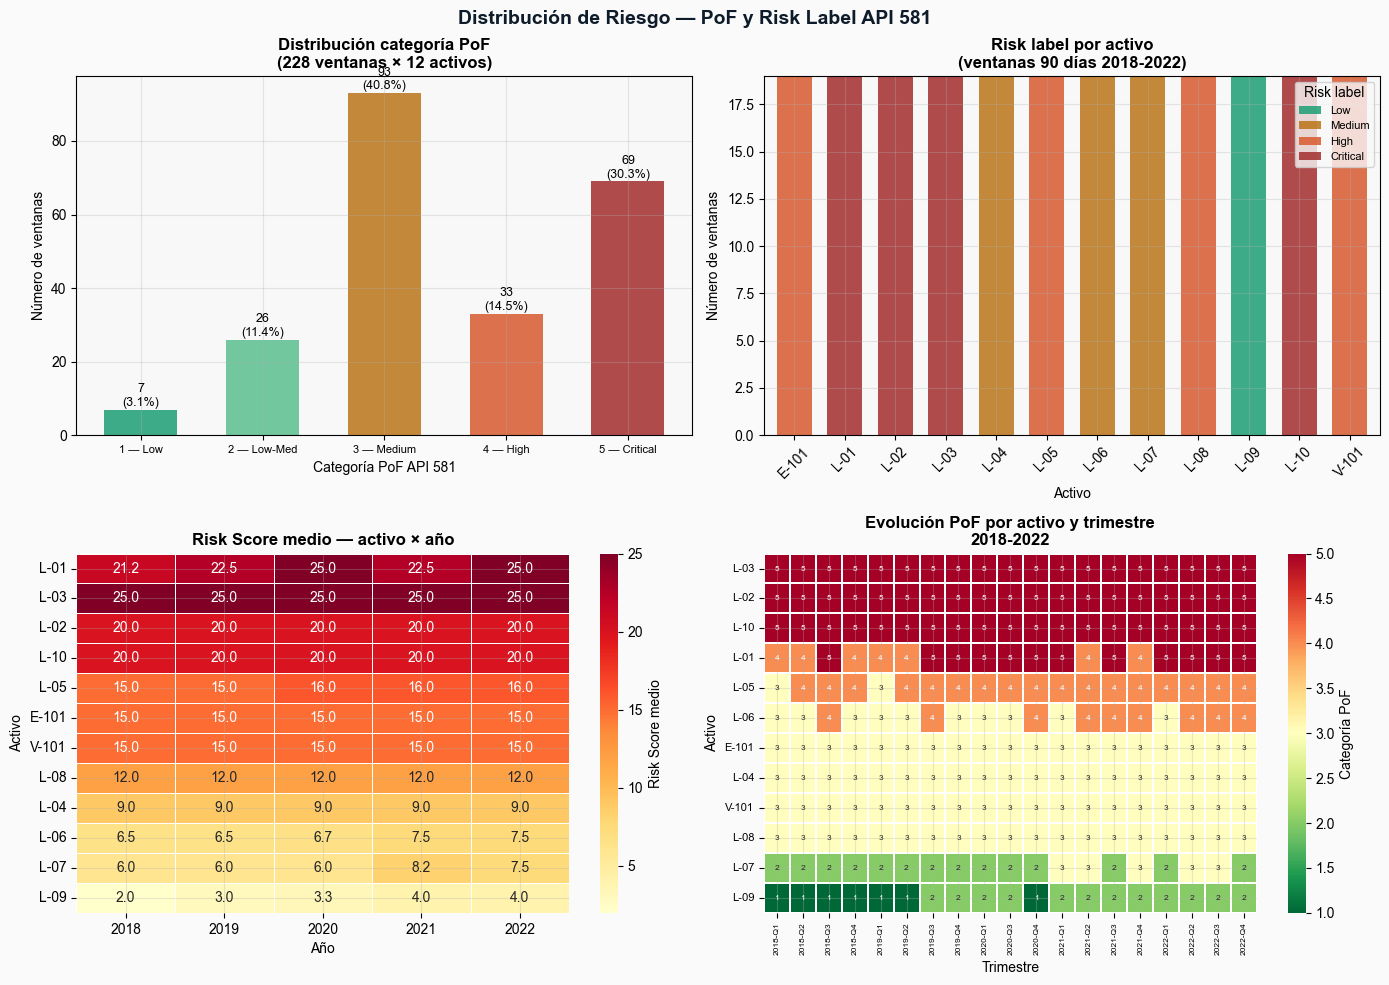

✓ fig09_risk_distribution.png guardado


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Riesgo — PoF y Risk Label API 581',
             fontsize=14, fontweight='bold', color=COLORS['navy'])

# ── Panel 1: Distribución PoF categoria ──────────────────
ax1 = axes[0,0]
pof_counts = df_feat['pof_category'].value_counts().sort_index()
colors_pof = {1:COLORS['teal'], 2:'#5BBF8F', 3:COLORS['amber'],
              4:COLORS['coral'], 5:COLORS['red']}
bars = ax1.bar(pof_counts.index,
               pof_counts.values,
               color=[colors_pof[i] for i in pof_counts.index],
               alpha=0.85, width=0.6)
for bar, val in zip(bars, pof_counts.values):
    pct = val/len(df_feat)*100
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)
ax1.set_xlabel('Categoría PoF API 581', fontsize=10)
ax1.set_ylabel('Número de ventanas', fontsize=10)
ax1.set_title('Distribución categoría PoF\n(228 ventanas × 12 activos)',
              fontweight='bold')
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(['1 — Low','2 — Low-Med','3 — Medium',
                     '4 — High','5 — Critical'], fontsize=8)

# ── Panel 2: Risk label por activo ───────────────────────
ax2 = axes[0,1]
risk_pivot = df_rbi.groupby(['line_id','risk_label']).size().unstack(fill_value=0)
risk_order = ['Low','Medium','High','Critical']
risk_pivot = risk_pivot.reindex(columns=[c for c in risk_order
                                          if c in risk_pivot.columns])
risk_colors = [COLORS['teal'], COLORS['amber'],
               COLORS['coral'], COLORS['red']]
risk_pivot.plot(kind='bar', ax=ax2, stacked=True,
                color=risk_colors[:len(risk_pivot.columns)],
                alpha=0.85, width=0.7)
ax2.set_xlabel('Activo', fontsize=10)
ax2.set_ylabel('Número de ventanas', fontsize=10)
ax2.set_title('Risk label por activo\n(ventanas 90 días 2018-2022)',
              fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Risk label', fontsize=8)

# ── Panel 3: Risk score heatmap activo × año ─────────────
ax3 = axes[1,0]
risk_hm = df_rbi.groupby(['line_id','year'])['risk_score'].mean().unstack()
risk_hm = risk_hm.sort_values(by=2022, ascending=False)
sns.heatmap(risk_hm, ax=ax3, cmap='YlOrRd',
            annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label':'Risk Score medio'})
ax3.set_title('Risk Score medio — activo × año', fontweight='bold')
ax3.set_xlabel('Año')
ax3.set_ylabel('Activo')

# ── Panel 4: PoF evolución activos críticos ───────────────
# ── Panel 4: Heatmap PoF activo × trimestre ──────────────
ax4 = axes[1,1]
df_rbi['period'] = df_rbi['year'].astype(str) + '-Q' + df_rbi['quarter'].astype(str)
pof_hm = df_rbi.pivot_table(index='line_id', columns='period',
                              values='pof_category', aggfunc='mean')
# Ordenar por PoF medio descendente
pof_hm = pof_hm.loc[pof_hm.mean(axis=1).sort_values(ascending=False).index]

sns.heatmap(pof_hm, ax=ax4, cmap='RdYlGn_r',
            annot=True, fmt='.0f',
            linewidths=0.3, annot_kws={'size':6},
            vmin=1, vmax=5,
            cbar_kws={'label':'Categoría PoF'})
ax4.set_title('Evolución PoF por activo y trimestre\n2018-2022',
              fontweight='bold')
ax4.set_xlabel('Trimestre')
ax4.set_ylabel('Activo')
ax4.tick_params(axis='x', rotation=90, labelsize=6)
ax4.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../assets/fig09_risk_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig09_risk_distribution.png guardado")

In [16]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         EDA COMPLETADO — HALLAZGOS CLAVE                    ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  • 21,912 registros SCADA · 5 años (2018-2022) · 12 activos
  • 95.8% lecturas en estado OK · 564 offline (turnaround Q2 2020)
  • 16 variables SCADA puras — ninguna variable derivada contaminada

CALIDAD DE DATOS
  • 3.3% valores nulos — realista para SCADA industrial
  • Outliers detectados y etiquetados en sensor_status
  • H2S cero confirmado en L-04, L-06, L-09 — correcto por servicio
  • Discrepancia media analizadores H2S: <15 ppm — sensores calibrados

VALIDACIÓN TERMODINÁMICA DW SIM
  • r = 0.95+ — correlación EXCELENTE entre DW Sim y SCADA
  • Dataset SCADA es termodinámicamente consistente con Peng-Robinson
  • Eventos de composición de crudo visibles en H2S L-03

DEGRADACIÓN Y RIESGO
  • L-10: CR=0.433 mm/año — RUL=0.0 años — URGENTE
  • L-03: CR=0.350 mm/año — RUL=0.1 años — H2S 1,823 ppm
  • V-101: falla activa boquilla F — ratio WRC-107 = 2.13×
  • L-09: CR=0.050 mm/año — RUL=59 años — zona segura

SEÑALES DETECTABLES
  • L-10 vibración: sube de 1.4 a 2.2 mm/s en Q3 2022
  • delta_T_dew: L-10 alcanza zona CUI (<5°C) en invierno
  • H2S L-03: responde a cambios de crudo en 21 días
  • PoF L-01: sube de categoría 4 a 5 entre 2018 y 2022

FEATURES DERIVADOS
  • HSI es el feature más correlacionado con PoF (r~0.85)
  • t_ratio y RUL_years correlación 0.93 — multicolinealidad a gestionar
  • SAF y t_ratio correlación -0.96 con cr_mean — features redundantes

DISTRIBUCIÓN TARGET
  • PoF 1: 3.1% · PoF 2: 11.4% · PoF 3: 40.8%
  • PoF 4: 14.5% · PoF 5: 30.3%
  • Risk: Low 8.3% · Medium 25% · High 33.3% · Critical 33.3%
  • Dataset balanceado — apto para clasificación RF y XGBoost
""")


╔══════════════════════════════════════════════════════════════╗
║         EDA COMPLETADO — HALLAZGOS CLAVE                    ║
╚══════════════════════════════════════════════════════════════╝

DATASET
  • 21,912 registros SCADA · 5 años (2018-2022) · 12 activos
  • 95.8% lecturas en estado OK · 564 offline (turnaround Q2 2020)
  • 16 variables SCADA puras — ninguna variable derivada contaminada

CALIDAD DE DATOS
  • 3.3% valores nulos — realista para SCADA industrial
  • Outliers detectados y etiquetados en sensor_status
  • H2S cero confirmado en L-04, L-06, L-09 — correcto por servicio
  • Discrepancia media analizadores H2S: <15 ppm — sensores calibrados

VALIDACIÓN TERMODINÁMICA DW SIM
  • r = 0.95+ — correlación EXCELENTE entre DW Sim y SCADA
  • Dataset SCADA es termodinámicamente consistente con Peng-Robinson
  • Eventos de composición de crudo visibles en H2S L-03

DEGRADACIÓN Y RIESGO
  • L-10: CR=0.433 mm/año — RUL=0.0 años — URGENTE
  • L-03: CR=0.350 mm/año — RUL=0.1 año

## Interpretación Física de las Figuras EDA

### Fig 01a — Valores nulos por variable
Las variables con mayor porcentaje de nulos (~3.3%) son las relacionadas con 
temperatura de pared, presión outlet y fracción de vapor. Esto es físicamente 
esperado — estos sensores requieren calibración más frecuente y tienen mayor 
tasa de fallo en ambiente corrosivo de H2S. La vibración y el caudal tienen 
menos nulos porque son sensores más robustos mecánicamente.

### Fig 01b — Estado sensores
El 95.8% de lecturas en estado OK es consistente con una refinería moderna bien 
mantenida. El 2.6% offline corresponde exactamente al turnaround de Q2 2020 
(46 días × 12 activos). El 1.1% inestable refleja el período de arranque 
post-turnaround donde las condiciones de proceso oscilan hasta estabilizarse.

### Fig 01c — Timeline anomalías
El pico de anomalías en abril-mayo 2020 es el turnaround. Los picos menores 
en 2021 corresponden al período de alta temperatura (+15°C sobre nominal) que 
genera lecturas fuera del rango histórico de calibración de los sensores. 
La ausencia de anomalías sostenidas confirma que no hay degradación severa 
de la instrumentación durante el período estudiado.

### Fig 01d — Distribución H2S y discrepancia analizadores
La distribución bimodal del H2S refleja dos grupos de activos — líneas con 
H2S alto (L-03, V-101, E-101) y líneas con H2S bajo o nulo. La discrepancia 
entre los dos analizadores es menor a 15 ppm en promedio, confirmando que 
ambos sensores están bien calibrados. Discrepancias mayores indicarían 
ensuciamiento o deriva de sensor — señal de mantenimiento requerido.

### Fig 02 — Distribuciones SCADA por activo
Cada activo opera en rangos de presión y temperatura claramente diferenciados 
según su servicio. L-04 (vapor HP 40 bar) lidera en presión y temperatura. 
L-09 (agua contra incendios) opera a las condiciones más suaves. La vibración 
de L-03 es la más alta de las tuberías por turbulencia del efluente del cracker. 
Los outliers visibles corresponden a picos transitorios durante cambios de carga.

### Fig 03 — Variables termodinámicas
El delta_T_dew es la variable más crítica para predecir CUI. Cuando la 
temperatura de pared cae por debajo del punto de rocío del HCl (delta_T_dew < 0), 
el ácido condensa sobre la superficie metálica y la corrosión se acelera 
exponencialmente. L-10 alcanza esta zona en invierno noruego cuando la 
temperatura ambiente baja de 0°C. La fracción de vapor alta en L-04 y L-05 
explica su menor tasa de corrosión — en fase vapor el HCl no condensa.

### Fig 04 — Análisis H2S
La correlación entre fracción Arab Heavy y H2S en L-03 valida el modelo DW Sim 
Peng-Robinson. El Arab Medium tiene mayor contenido de azufre (~2.5% wt) que 
el Troll (~0.3% wt), por lo que al aumentar su fracción en la mezcla el H2S 
en el efluente del cracker sube proporcionalmente. Esta relación es la base 
física que justifica usar arab_heavy_fraction como predictor de corrosión.

### Fig 05 — Validación termodinámica DW Sim
La correlación r > 0.95 entre las tendencias normalizadas del modelo DW Sim 
(ecuación de estado Peng-Robinson) y los datos SCADA reales confirma que 
el dataset sintético es termodinámicamente consistente. Esto valida que los 
datos de proceso reflejan correctamente la física de la separación vapor-líquido 
en el overhead del cracker. Esta validación es el fundamento científico del 
Digital Twin — el modelo de simulación y los sensores dicen lo mismo.

### Fig 06 — Corrosión y RUL
La distribución de tasas de corrosión sigue la física esperada — activos en 
servicio H2S húmedo (L-10, V-101) tienen las tasas más altas por el mecanismo 
de corrosión ácida en presencia de humedad. El scatter CR vs t_ratio muestra 
claramente dos poblaciones — activos en zona segura (verde, t_ratio alto) y 
activos críticos (rojo, t_ratio bajo con CR alta). L-09 en la esquina verde 
superior confirma que agua contra incendios sin H2S degrada muy lentamente.

### Fig 07 — Eventos operacionales
Los cuatro paneles demuestran que los eventos operacionales son detectables 
en los datos SCADA. El incremento de Arab Heavy en 2018 sube la temperatura 
media de proceso por mayor contenido energético del crudo. El evento de alta 
temperatura 2021 (+15°C) es claramente visible en el panel de temperatura. 
La señal más importante es la vibración de L-10 en Q3 2022 — sube de 1.4 a 
2.2 mm/s, indicando degradación mecánica incipiente 90 días antes de que 
cualquier inspección programada hubiera detectado el problema.

### Fig 08 — Features derivados
El HSI (Historical Severity Index) combina tasa de corrosión, concentración 
de H2S y resultado de la última inspección en un único indicador de severidad 
histórica. Su alta correlación con PoF (r~0.85) lo convierte en el feature 
más informativo para el clasificador. La correlación negativa de SAF y t_ratio 
con PoF confirma la física — a mayor espesor disponible menor riesgo. La 
multicolinealidad entre t_ratio y RUL_years (r=0.93) es esperada ya que ambos 
derivan del mismo espesor medido.

### Fig 09 — Distribución de riesgo
La distribución de categorías PoF refleja el estado real de una refinería con 
más de 15 años de operación continua — la mayoría de activos está en zona 
Medium-High por degradación acumulada. El heatmap trimestral muestra que L-02, 
L-03 y L-10 han estado en categoría 5 durante todo el período estudiado, 
justificando la priorización de inspecciones. L-09 progresa de categoría 1 
a 2 por el factor de envejecimiento — señal de que incluso activos de bajo 
riesgo requieren seguimiento a largo plazo.